In [1]:
import os
import pandas as pd
import seaborn as sns
import sys
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller, kpss, acf

In [9]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..', 'src')))

from scripts.plot_config import set_seaborn
set_seaborn()

In [3]:
df= pd.read_csv(
    "../../data/processed/processed_water.csv",
    index_col="DATA_VENCIMENTO",
    parse_dates=["DATA_VENCIMENTO"]
)

df = df["VALOR_FATURA"]
display(df.head(3))

DATA_VENCIMENTO
2022-02-15    24.24
2022-02-15    24.24
2022-02-15    74.82
Name: VALOR_FATURA, dtype: float64

### Correlograma - Ruído Branco

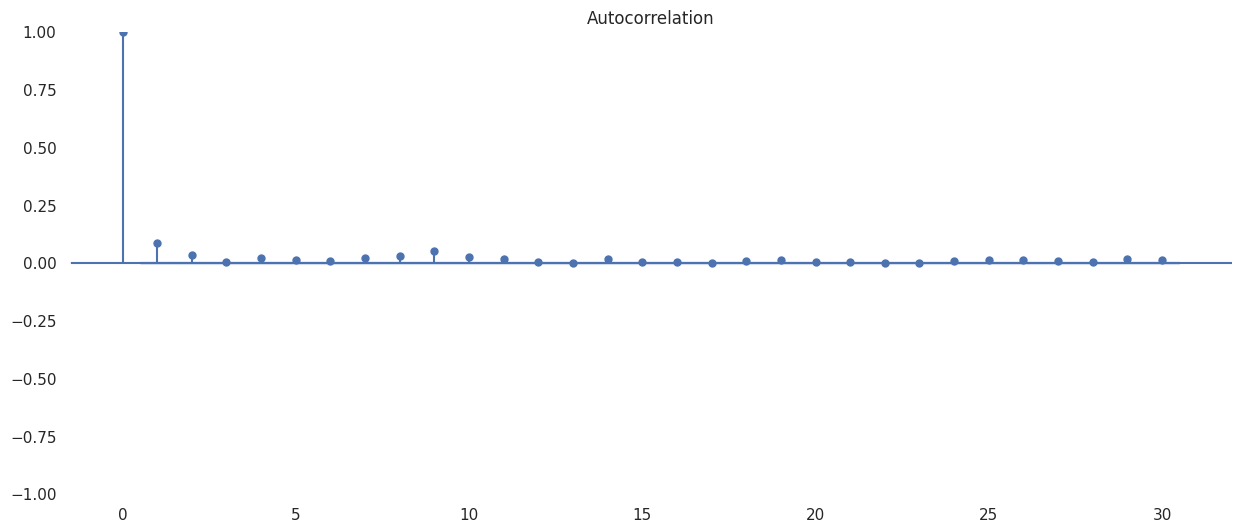

In [11]:
plot_acf(df, lags=30);

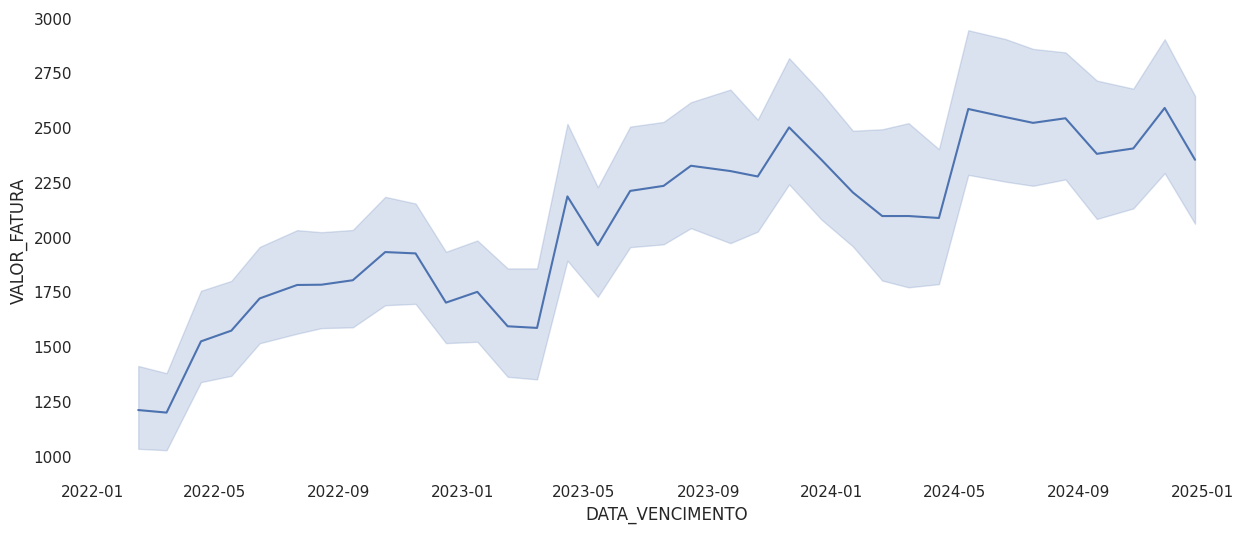

In [12]:
sns.lineplot(df);

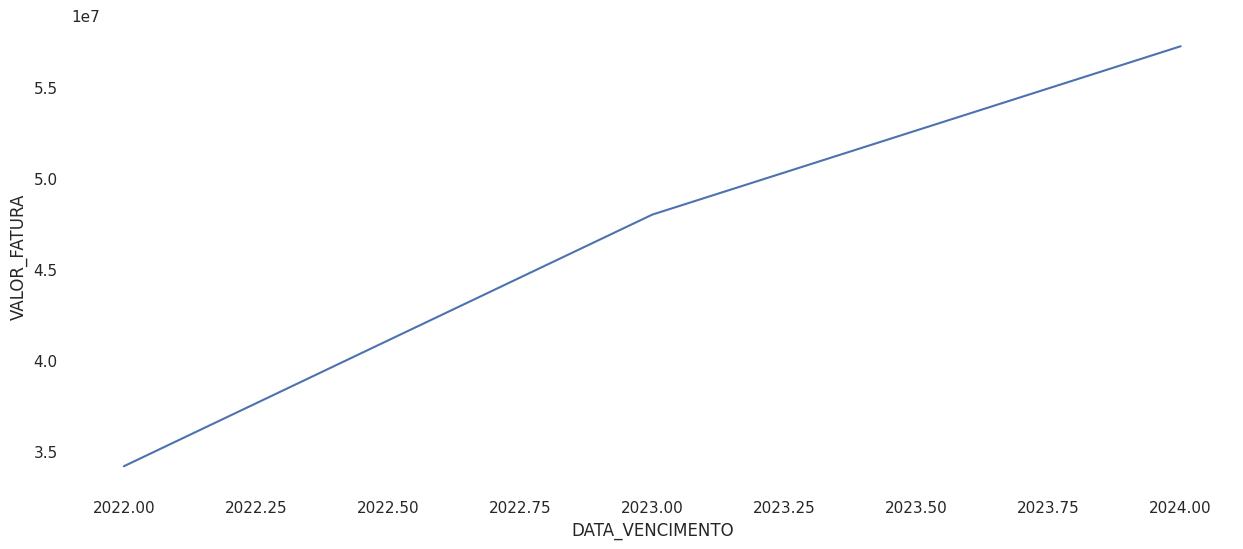

In [13]:
# Eliminação do ruído para análise de tendência

e_ruido= df.groupby(df.index.year).sum()
sns.lineplot(e_ruido);

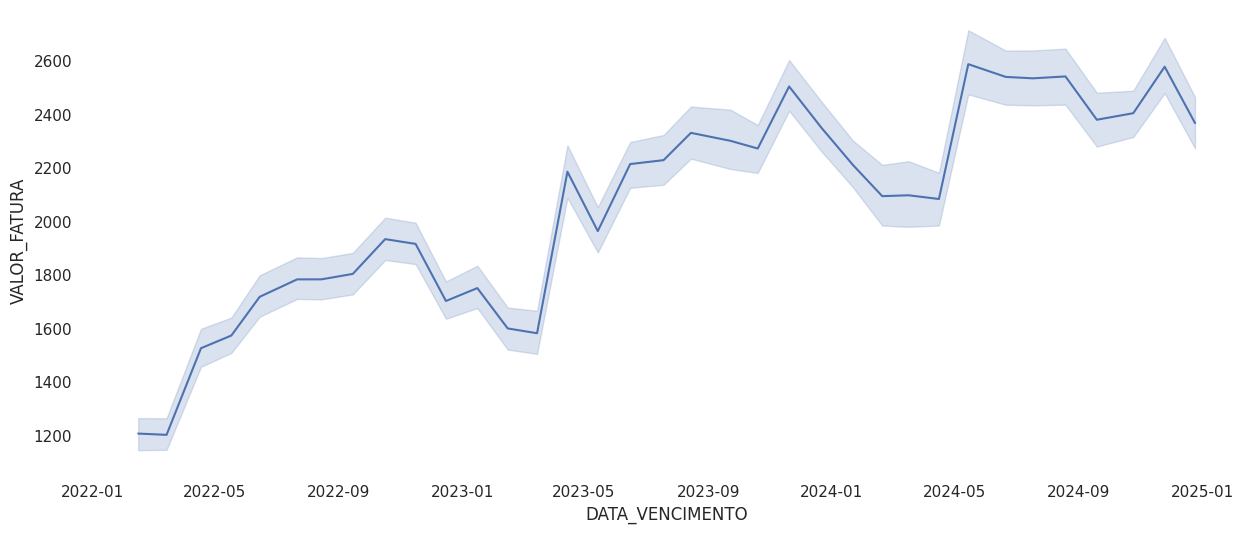

In [14]:
# Eliminação do ruído com média movel simples para análise de tendência

media_movel= df.rolling(12).mean()
sns.lineplot(media_movel);

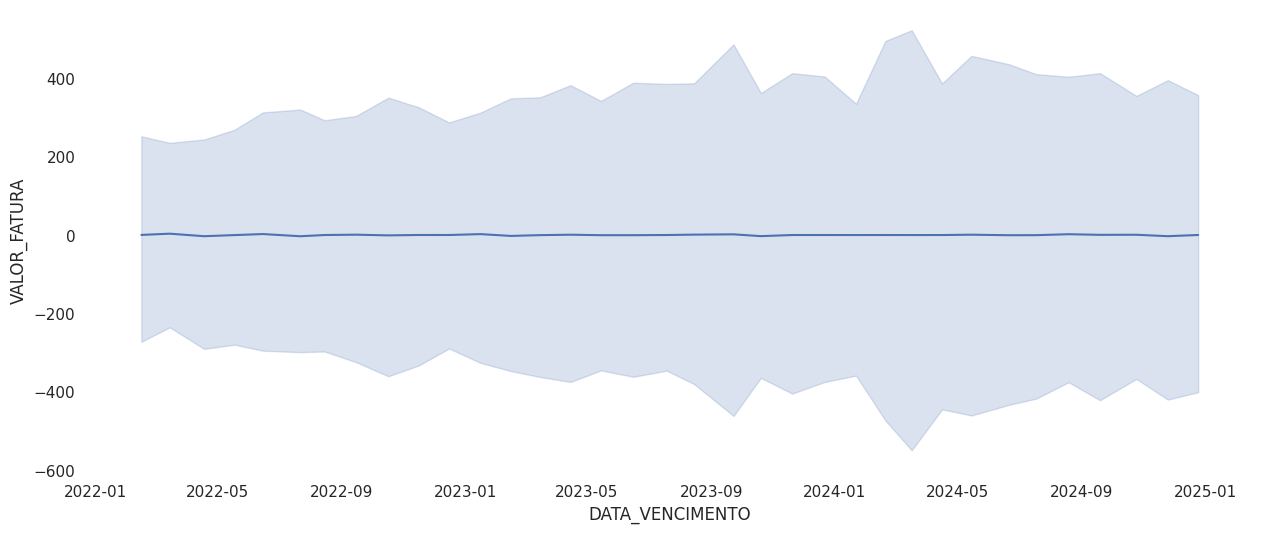

In [15]:
diferenca= df.diff(1)
sns.lineplot(diferenca);